In [98]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

df = pd.read_csv('winequality-red.csv')

print(df.shape)
print(df.head(3))
quality_counts = df['quality'].value_counts().sort_index()
for q, cnt in quality_counts.items():
    print(f"  quality={q}: {cnt} образцов ({cnt/len(df)*100:.1f}%)")
    
y = df['quality'].values
X = df.drop('quality', axis=1).values

(1599, 12)
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   

   alcohol  quality  
0      9.4        5  
1      9.8        5  
2      9.8        5  
  quality=3: 10 образцов (0.6%)
  quality=4: 53 образцов (3.3%)
  quality=5: 681 образцов (42.6%)
  quality=6: 638 образцов (39.9%)
  quality=7: 199 образцов (12.4%)
  quality=8: 18 образцов (1.1%)



RandomForest:
  Accuracy: 0.6406

  Classification Report:
              precision    recall  f1-score   support

   quality_3       0.00      0.00      0.00         4
   quality_4       0.00      0.00      0.00        21
   quality_5       0.69      0.77      0.73       273
   quality_6       0.60      0.67      0.63       255
   quality_7       0.61      0.35      0.44        80
   quality_8       0.33      0.14      0.20         7

    accuracy                           0.64       640
   macro avg       0.37      0.32      0.33       640
weighted avg       0.61      0.64      0.62       640



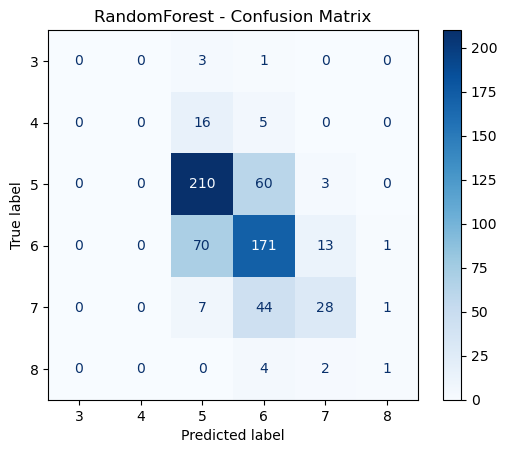

/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:470: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



LogisticRegression:
  Accuracy: 0.6031

  Classification Report:
              precision    recall  f1-score   support

   quality_3       0.00      0.00      0.00         4
   quality_4       0.00      0.00      0.00        21
   quality_5       0.67      0.77      0.71       273
   quality_6       0.54      0.65      0.59       255
   quality_7       0.63      0.15      0.24        80
   quality_8       0.00      0.00      0.00         7

    accuracy                           0.60       640
   macro avg       0.31      0.26      0.26       640
weighted avg       0.58      0.60      0.57       640



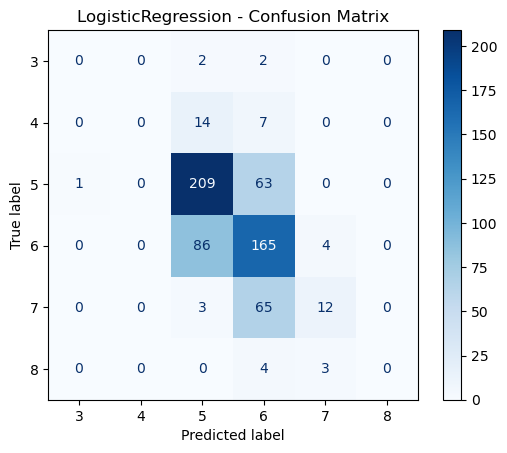

In [99]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.4, random_state=42, stratify=y
)

models = {
    'RandomForest': RandomForestClassifier(n_estimators=100, random_state=42),
    'LogisticRegression': LogisticRegression(max_iter=5000, random_state=42)
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    print(f"\n{name}:")
    print(f"  Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    
    all_labels = sorted(np.unique(y))
    target_names = [f"quality_{i}" for i in all_labels]
    
    print(f"\n  Classification Report:")
    print(classification_report(y_test, y_pred, labels=all_labels, target_names=target_names, zero_division=0))
    
    ConfusionMatrixDisplay.from_estimator(model, X_test, y_test, 
                                          display_labels=all_labels,
                                          cmap='Blues')
    plt.title(f"{name} - Confusion Matrix")
    plt.show()



              precision    recall  f1-score   support

   quality_3       0.00      0.00      0.00         4
   quality_4       0.00      0.00      0.00        21
   quality_5       0.69      0.77      0.73       273
   quality_6       0.60      0.67      0.64       255
   quality_7       0.63      0.36      0.46        80
   quality_8       1.00      0.14      0.25         7

    accuracy                           0.65       640
   macro avg       0.49      0.33      0.35       640
weighted avg       0.62      0.65      0.62       640



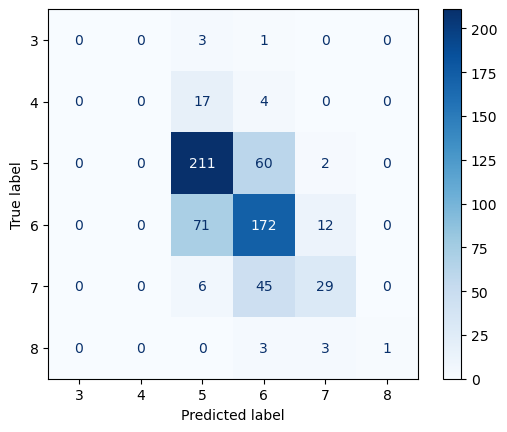

In [100]:

rf_balanced = RandomForestClassifier(
    n_estimators=100, 
    random_state=42,
    class_weight="balanced",
)



rf_balanced.fit(X_train, y_train)
y_pred_bal = rf_balanced.predict(X_test)

print(classification_report(y_test, y_pred_bal, labels=all_labels, target_names=target_names, zero_division=0))

ConfusionMatrixDisplay.from_estimator(rf_balanced, X_test, y_test, 
                                          display_labels=all_labels,
                                          cmap='Blues')
plt.show()

In [101]:
%pip install imblearn
from imblearn.over_sampling import SMOTE

              precision    recall  f1-score   support

   quality_3       0.11      0.25      0.15         4
   quality_4       0.16      0.29      0.21        21
   quality_5       0.73      0.67      0.70       273
   quality_6       0.63      0.58      0.61       255
   quality_7       0.47      0.51      0.49        80
   quality_8       0.10      0.29      0.14         7

    accuracy                           0.60       640
   macro avg       0.37      0.43      0.38       640
weighted avg       0.63      0.60      0.61       640



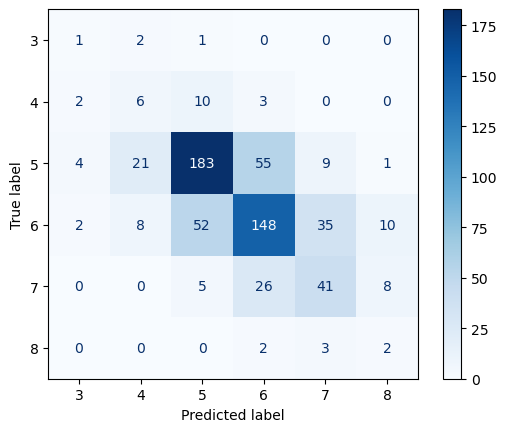

In [102]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
rf_smote = RandomForestClassifier(    
    n_estimators=100, 
    random_state=42,
    max_depth=10,
)
rf_smote.fit(X_train_smote, y_train_smote)
y_pred_smote = rf_smote.predict(X_test)
print(classification_report(y_test, y_pred_smote, labels=all_labels, target_names=target_names, zero_division=0))
ConfusionMatrixDisplay.from_estimator(rf_smote, X_test, y_test, 
                                          display_labels=all_labels,
                                          cmap='Blues')
plt.show()

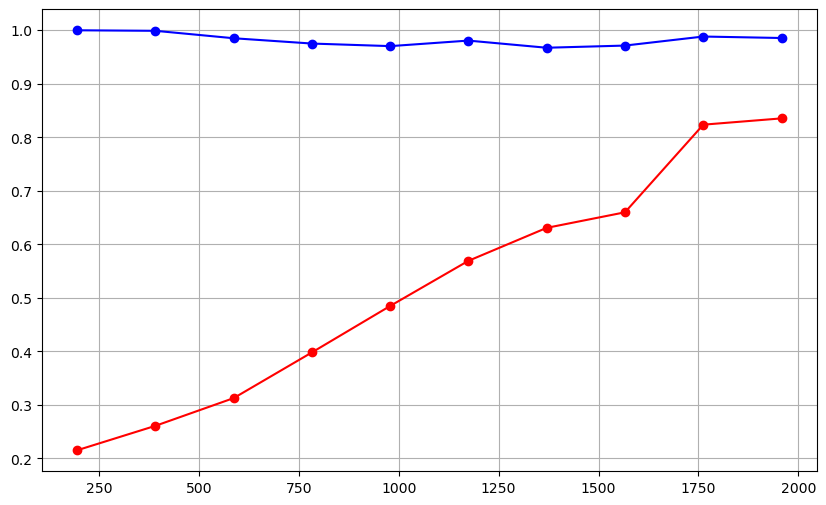

In [103]:
from sklearn.model_selection import train_test_split, learning_curve, GridSearchCV, StratifiedKFold
train_sizes, train_scores, test_scores = learning_curve(
    rf_smote, X_train_smote, y_train_smote,
    scoring='f1_macro',
    train_sizes=np.linspace(0.1, 1.0, 10),
    random_state=42,
    n_jobs=-1
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, 'o-', color='blue')
plt.plot(train_sizes, test_mean, 'o-', color='red')
plt.grid(True)
plt.show()



In [104]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_predict, cross_val_score

pipeline = Pipeline([
    ('rf', RandomForestClassifier(random_state=42))
])

param_grid = {
    'rf__max_depth': [3, 5, 10, None],
    'rf__n_estimators': [25, 50, 100],
   # 'rf__class_weight': ['balanced'],
    'rf__min_samples_split': [5, 10, 20]
}

param_grid1 = {
    'rf__max_depth': [10],
    'rf__n_estimators': [100],
    'rf__class_weight': ['balanced'],
    'rf__min_samples_split': [10]
}
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=cv,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_smote, y_train_smote)

print(grid_search.best_params_)

best_pipeline = grid_search.best_estimator_

y_pred_final = best_pipeline.predict(X_test)
print(classification_report(y_test, y_pred_final, zero_division=0))

Fitting 3 folds for each of 36 candidates, totalling 108 fits
{'rf__max_depth': None, 'rf__min_samples_split': 5, 'rf__n_estimators': 100}
              precision    recall  f1-score   support

           3       0.17      0.25      0.20         4
           4       0.28      0.43      0.34        21
           5       0.73      0.69      0.71       273
           6       0.63      0.62      0.62       255
           7       0.50      0.49      0.49        80
           8       0.12      0.29      0.17         7

    accuracy                           0.62       640
   macro avg       0.40      0.46      0.42       640
weighted avg       0.64      0.62      0.63       640



In [ ]:
Базовая модель (практика 3) - 0.33
+ SMOTE / class_weight - 0.38
+ GridSearchCV - 0.42